In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

c:\Users\Dell\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_US = df[(df['job_country'] == 'United States')]

In [5]:
df_plot = df_US['job_title_short'].value_counts().to_frame()

Text(0.5, 0, 'Number of Job Posts')

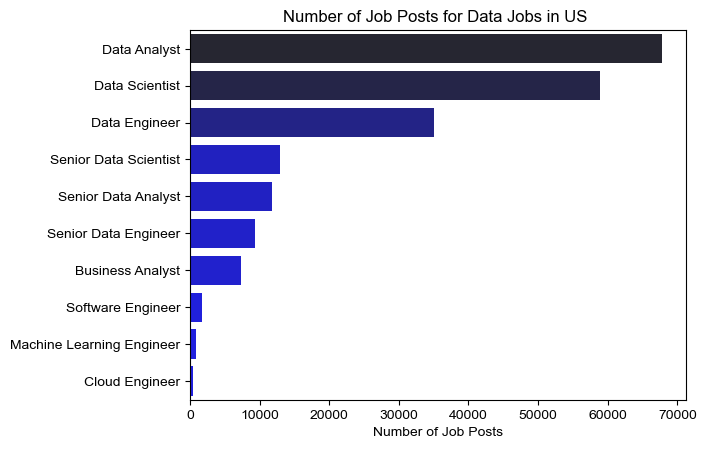

In [6]:
sns.barplot(data=df_plot,x='count',y=df_plot.index,hue='count',legend= False,palette = 'dark:b_r')
sns.set_theme(style='ticks')
plt.title('Number of Job Posts for Data Jobs in US ')
plt.ylabel('')
plt.xlabel('Number of Job Posts')


In [7]:
df_copy = df.copy()

In [8]:
df_copied = df_copy['job_country'].value_counts().head(20).to_frame()

Text(0.5, 0, 'Number of Job Posts')

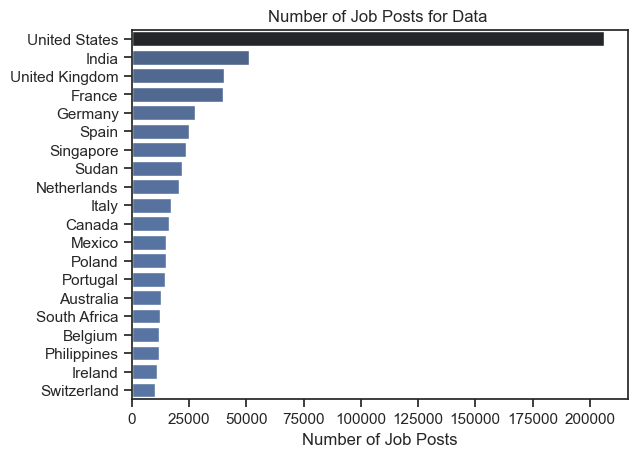

In [9]:
sns.barplot(data=df_copied,x='count',y=df_copied.index,hue='count',palette='dark:b_r',legend=False)
sns.set_theme(style='ticks')
plt.title('Number of Job Posts for Data ')
plt.ylabel('')
plt.xlabel('Number of Job Posts')


In [10]:
df_companies = df['company_name'].value_counts().head(20).to_frame()[0:]

In [11]:
df_companies

,count
company_name,
Emprego,6664
Booz Allen Hamilton,2879
Dice,2827
Harnham,2547
Insight Global,2254
Citi,2164
Confidenziale,2040
Listopro,1984
Capital One,1946


Text(0.5, 0, 'Number of Job Posts')

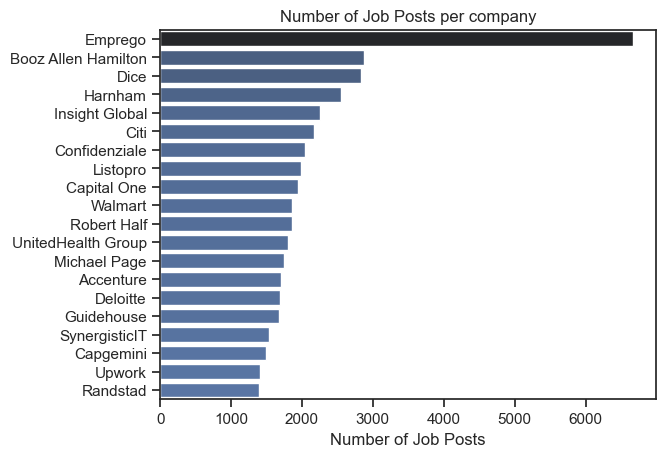

In [12]:
sns.barplot(data=df_companies,x='count',y=df_companies.index,legend=False,palette='dark:b_r',hue='count')
sns.set_theme(style='ticks')
plt.title('Number of Job Posts per company')
plt.ylabel('')
plt.xlabel('Number of Job Posts')


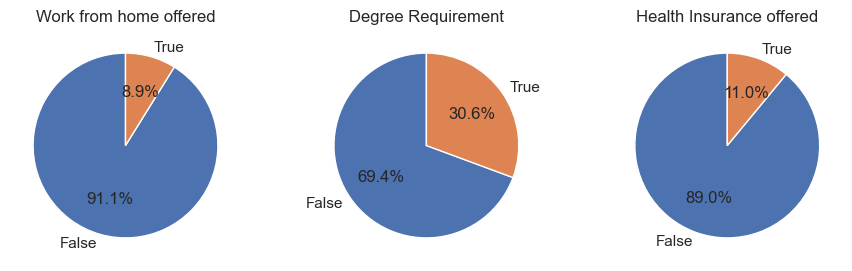

In [29]:
df_dict = {
    'job_work_from_home' : 'Work from home offered',
    'job_no_degree_mention' : 'Degree Requirement',
    'job_health_insurance' : 'Health Insurance offered'
}

fig,ax = plt.subplots(1,3,figsize=(11,3))

for i,(columns,items) in enumerate(df_dict.items()):
    values=df[columns].value_counts()
    ax[i].pie(values,labels = values.index,startangle= 90,autopct='%1.1f%%')
    ax[i].set_title(items)


In [32]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

In [40]:
df_plot = df_DA_US['job_location'].value_counts().to_frame().head(10)

Text(0.5, 0, 'Number of Job Posts')

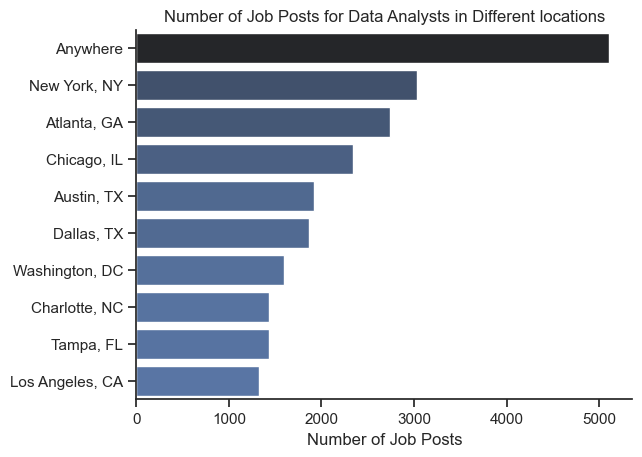

In [42]:
sns.barplot(data=df_plot,x='count',y=df_plot.index,legend=False,palette='dark:b_r',hue='count')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Number of Job Posts for Data Analysts in Different locations')
plt.ylabel('')
plt.xlabel('Number of Job Posts')


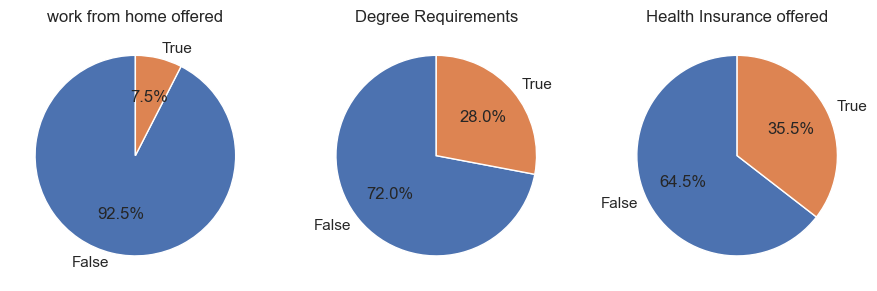

In [60]:
dict_column = {
    'job_work_from_home' : 'work from home offered',
    'job_no_degree_mention' : 'Degree Requirements',
    'job_health_insurance' : 'Health Insurance offered'
}

fig,ax = plt.subplots(1,3,figsize = (11,3.5))
for i,(column,title) in enumerate(dict_column.items()):
    values = (df_DA_US[column].value_counts())
    ax[i].pie(df_DA_US[column].value_counts(),labels = values.index, startangle=90, autopct = '%1.1f%%')
    ax[i].set_title(title)

In [49]:
df_cplot = df_DA_US['company_name'].value_counts().head(10).to_frame()

Text(0.5, 0, 'Number of Job Posts')

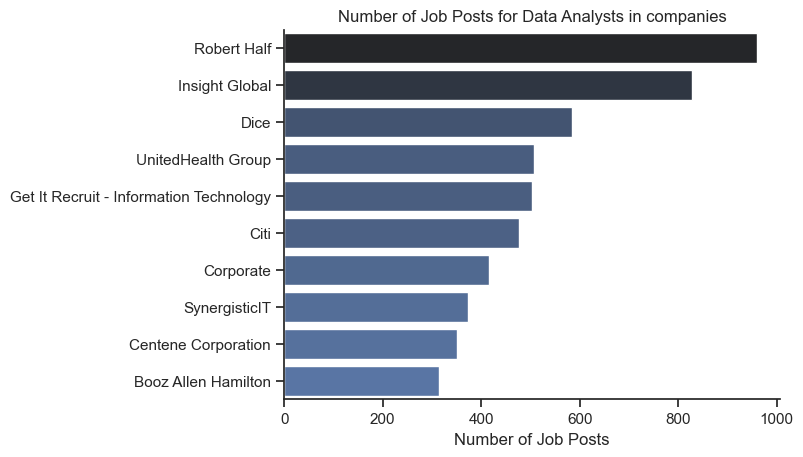

In [50]:
sns.barplot(data=df_cplot,x='count',y=df_cplot.index,legend=False,palette='dark:b_r',hue='count')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Number of Job Posts for Data Analysts in companies')
plt.ylabel('')
plt.xlabel('Number of Job Posts')